# Traffic Sign Classification

## Step 1: Download dataset

In [3]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [4]:
from google.colab import files
import zipfile

uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
for fn in uploaded.keys():
    zip_path = fn
    break

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

## Step 2: Load dataset

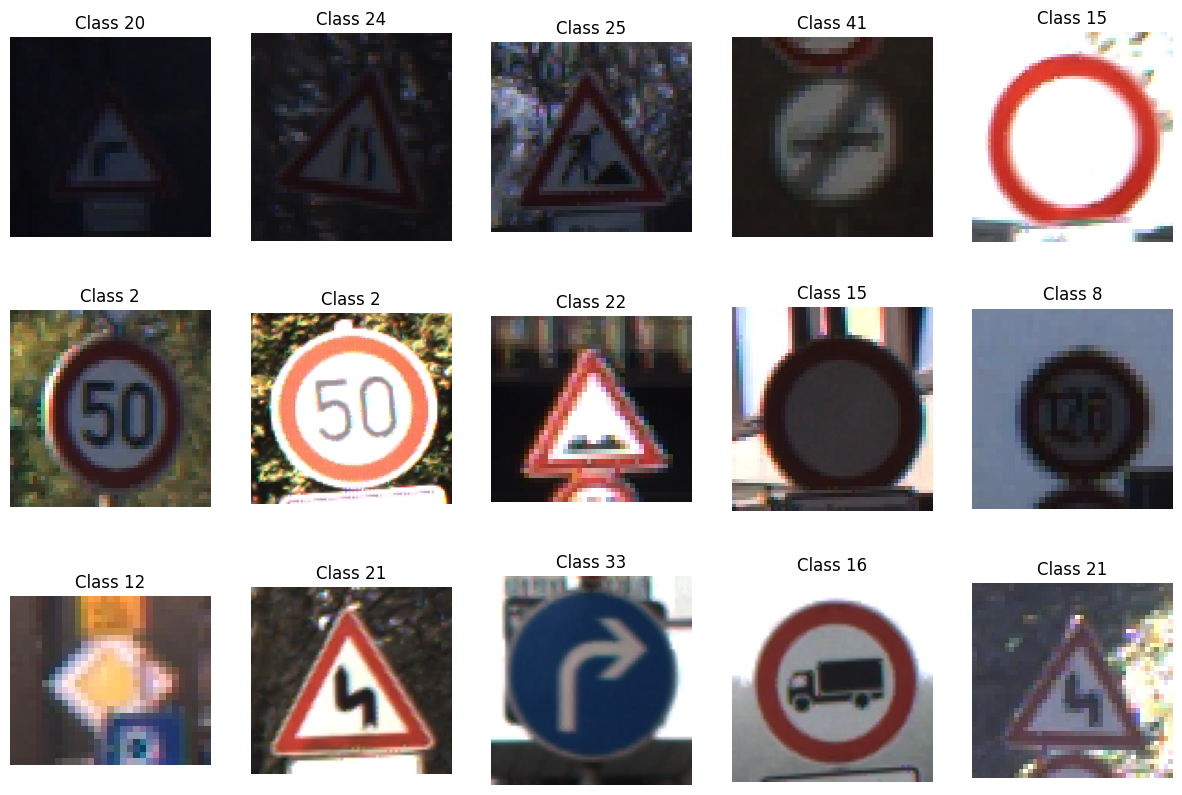

In [9]:
import random

root = 'dataset'

data = pd.read_csv(os.path.join(root, 'Train.csv'))

num_samples = 43

for ii in range(15):
    class_id = random.randint(0, 42)

    subset = data[data['ClassId'] == class_id]
    row = subset.sample().iloc[0]

    img = cv2.imread(os.path.join(root, row['Path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 5, ii+1), plt.imshow(img)
    plt.title(f"Class {class_id}"), plt.axis('off')

## Step 3: Class distribution

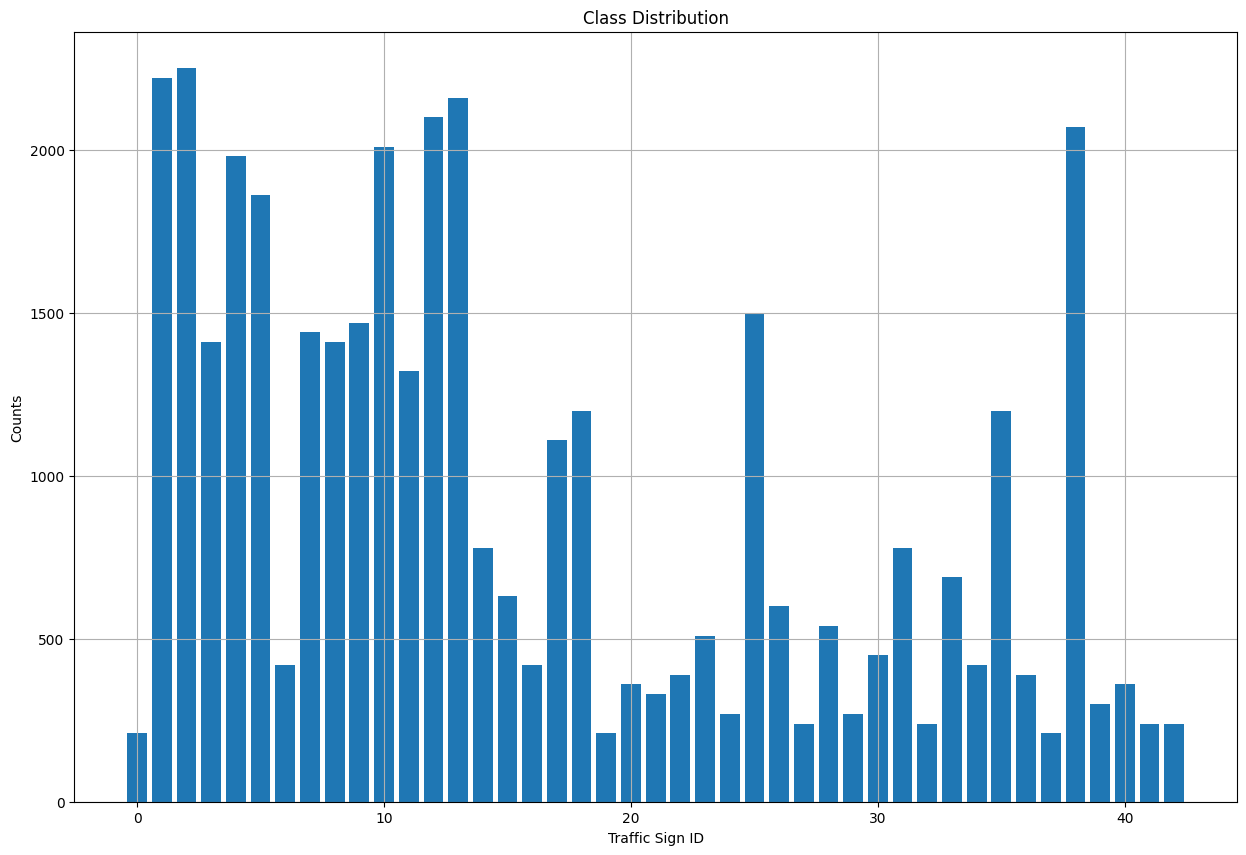

In [10]:
from collections import Counter

ids = data['ClassId']
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')
plt.title('Class Distribution')
plt.show()

## Answers

### Is the dataset balanced?
No, the dataset is not balanced. Some classes contain significantly more samples than others.

### Are there over- or under-represented classes?
Yes. Some classes are over-represented (many images)(ex.1,2), while others are under-represented (few images)(ex.19).

## Image size analysis

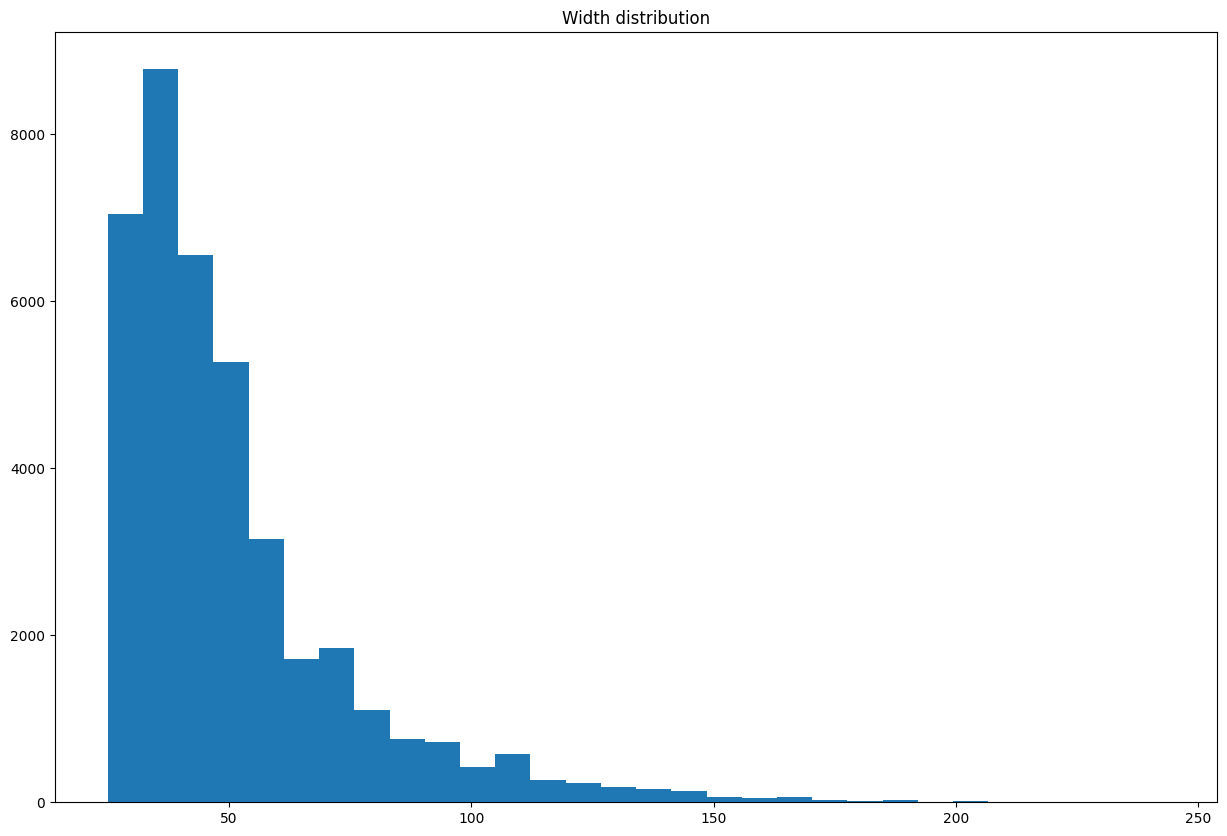

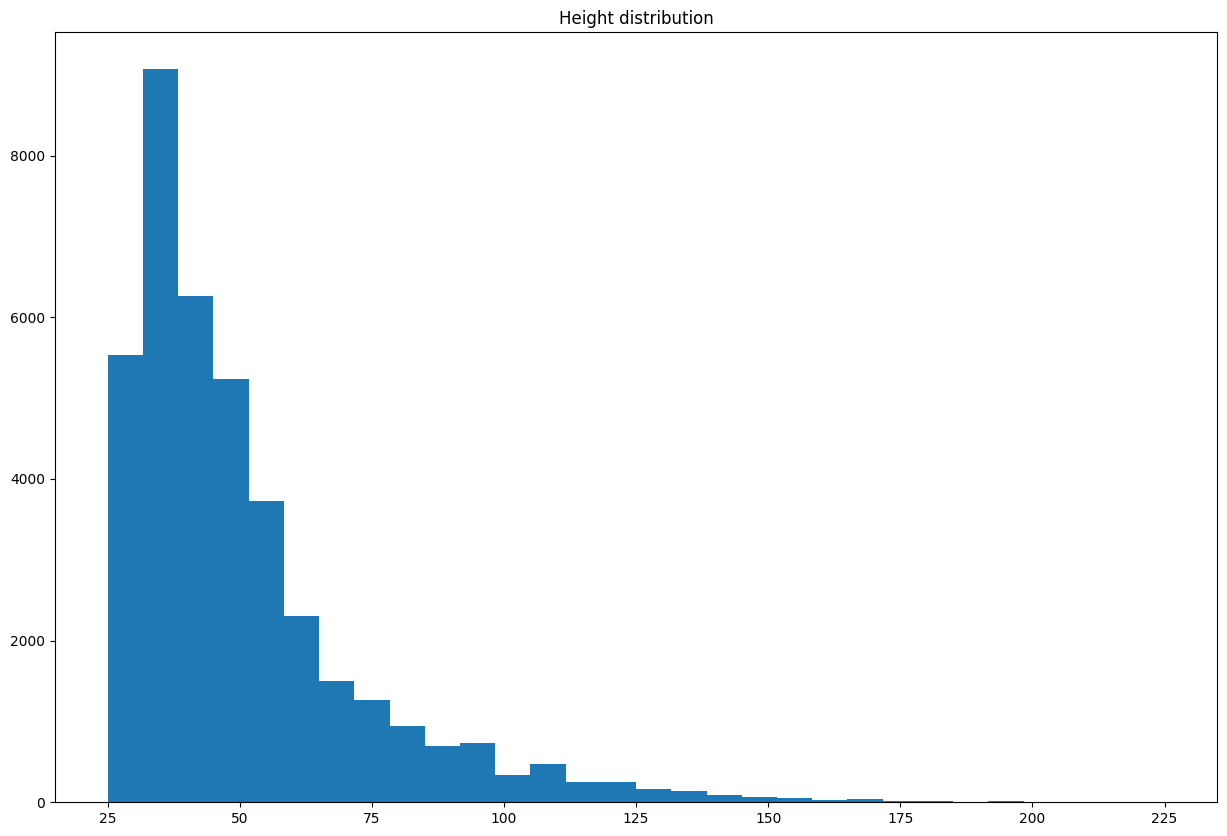

In [11]:
plt.hist(data['Width'], bins=30)
plt.title("Width distribution")
plt.show()

plt.hist(data['Height'], bins=30)
plt.title("Height distribution")
plt.show()

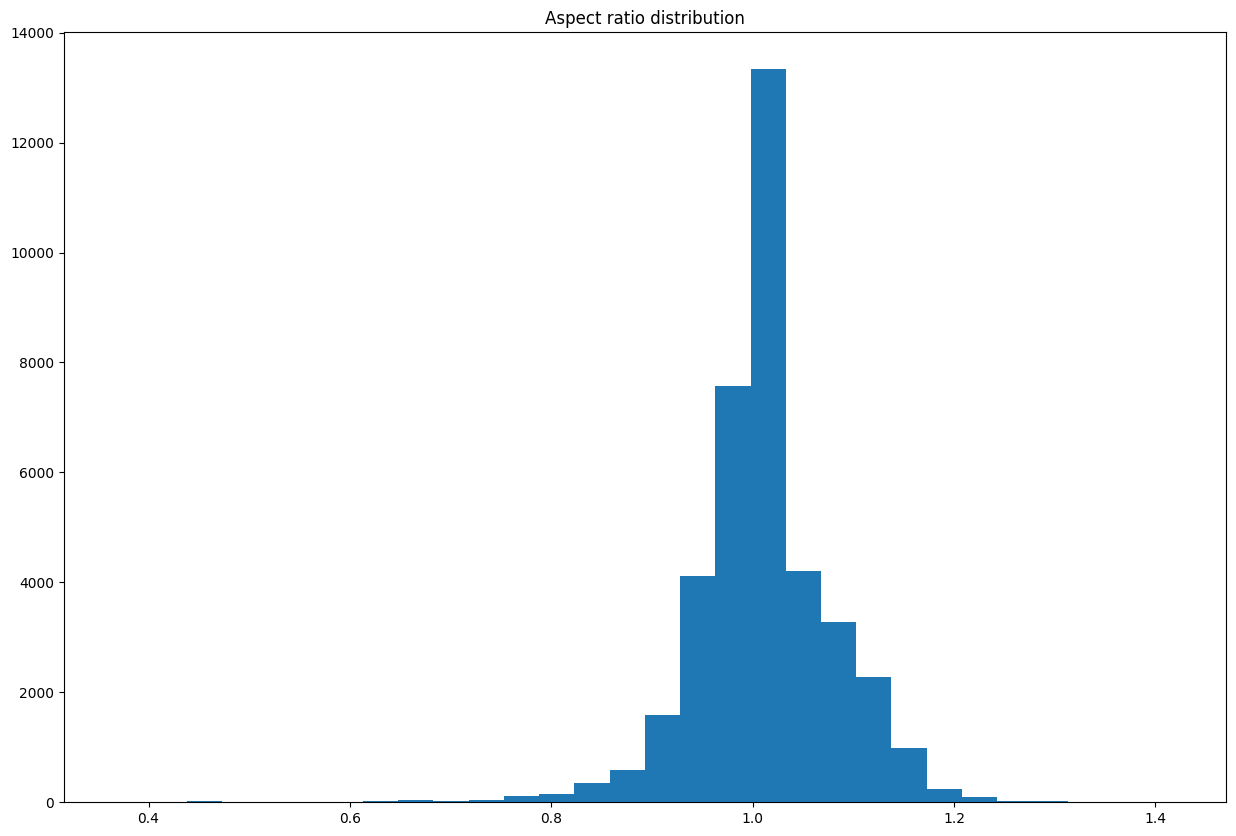

In [12]:
aspect_ratio = data['Width'] / data['Height']

plt.hist(aspect_ratio, bins=30)
plt.title("Aspect ratio distribution")
plt.show()

Изображения имеют различное пространственное разрешение (ширина и высота варьируются).
Также наблюдается разброс в соотношении сторон.
Перед обучением модели необходимо привести изображения к единому размеру, иначе модель не сможет корректно обрабатывать входные данные.

In [13]:
brightness = []

for i in range(len(data)):
    img_path = os.path.join(root, data.iloc[i]['Path'])
    img = cv2.imread(img_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness.append(gray.mean())

data['Brightness'] = brightness

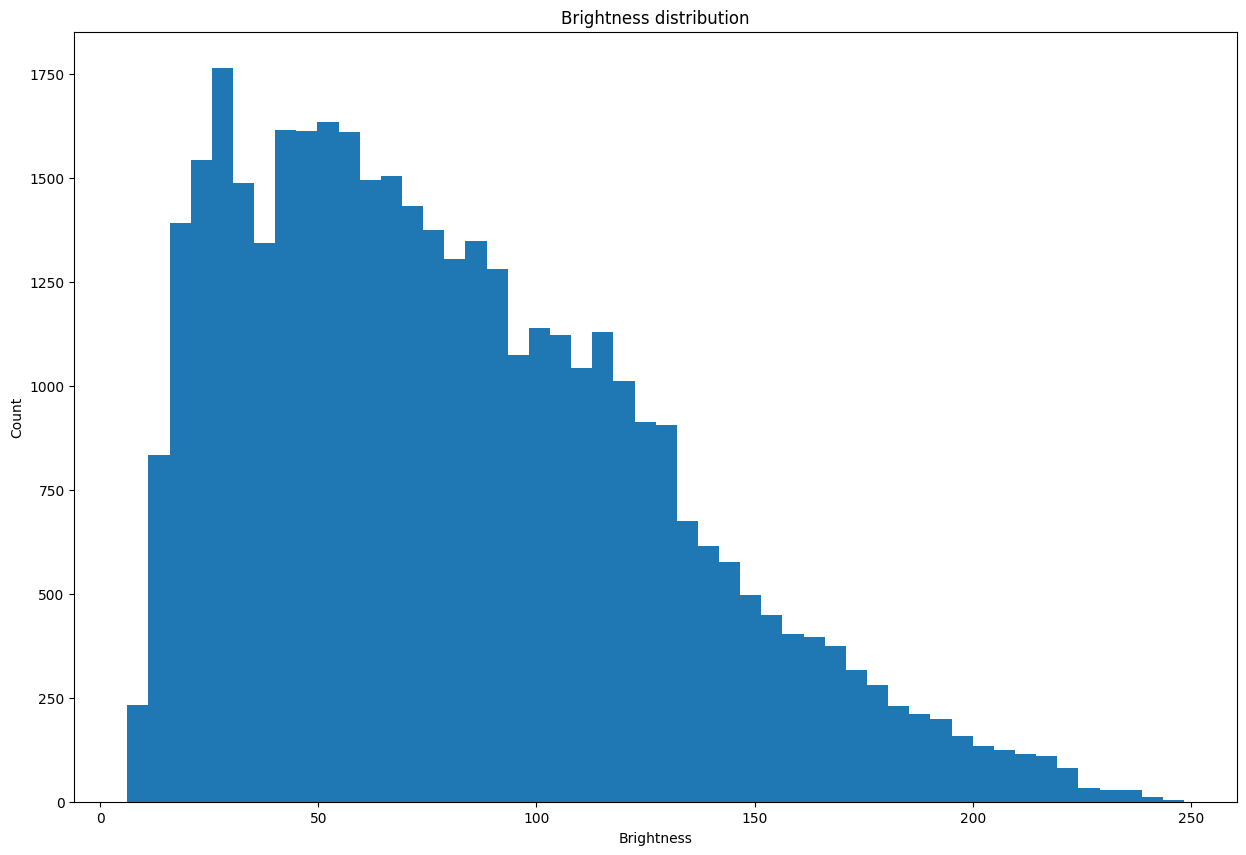

In [14]:
plt.hist(data['Brightness'], bins=50)
plt.title("Brightness distribution")
plt.xlabel("Brightness")
plt.ylabel("Count")
plt.show()

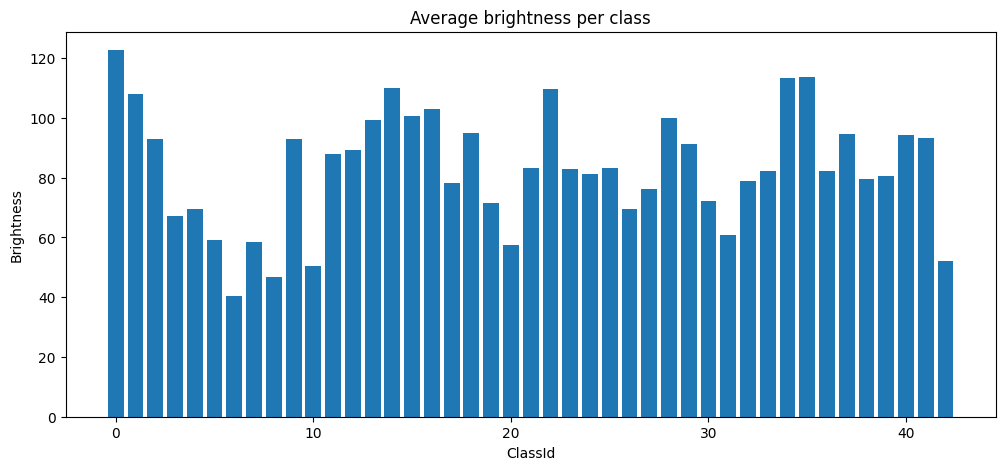

In [15]:
class_brightness = data.groupby('ClassId')['Brightness'].mean()

plt.figure(figsize=(12,5))
plt.bar(class_brightness.index, class_brightness.values)
plt.title("Average brightness per class")
plt.xlabel("ClassId")
plt.ylabel("Brightness")
plt.show()

In [16]:
print("Most dark classes:")
print(class_brightness.sort_values().head())

print("\nMost bright classes:")
print(class_brightness.sort_values(ascending=False).head())

Most dark classes:
ClassId
6     40.250423
8     46.908378
10    50.392712
42    52.030146
20    57.361867
Name: Brightness, dtype: float64

Most bright classes:
ClassId
0     122.700563
35    113.527621
34    113.344344
14    110.130700
22    109.747361
Name: Brightness, dtype: float64


Анализ яркости показал, что изображения имеют различный уровень освещённости. Некоторые классы в среднем темнее, другие — светлее.
Различия в яркости могут негативно влиять на обучение модели, так как модель может начать учитывать освещение вместо формы знака.
Для решения этой проблемы можно использовать нормализацию.